# How fast do the atoms move? The Maxwell-Boltzmann speed distribution
### a bell-with-a-tail, and the three speeds that summarize it

At temperature $T$ the atoms in a gas do not all move at one speed -- they have a spread,
the **Maxwell-Boltzmann distribution**:
$$f(v)=4\pi\left(\frac{m}{2\pi k T}\right)^{3/2} v^2\, e^{-m v^2 / 2kT}.$$
Two factors fight: the $v^2$ (more ways to aim a fast velocity in 3-D) lifts the curve off
zero, and the Boltzmann factor $e^{-\frac12 m v^2/kT}$ crushes the high-speed tail. Their
product is the lopsided bell every kinetic-theory chapter draws. This notebook plots it
with `dgs/maxwell_boltzmann.py`, marks the three characteristic speeds, and shows how the
curve shifts with temperature and molecular mass. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import maxwell_boltzmann as mb
k, amu = mb.K_BOLTZ, mb.AMU
print("ready -- N2 at 300 K: v_mp=%.0f, v_avg=%.0f, v_rms=%.0f m/s"
      % (mb.most_probable_speed(28*amu,300), mb.mean_speed(28*amu,300), mb.rms_speed(28*amu,300)))

ready -- N2 at 300 K: v_mp=422, v_avg=476, v_rms=517 m/s


## 1. Why the shape: rising $v^2$ times falling $e^{-\alpha v^2}$

Plot the two competing factors and their product. The $v^2$ term alone would grow forever;
the exponential alone peaks at $v=0$. Multiplied, the peak lands at a finite **most probable
speed** and a long tail stretches to the right -- a few atoms are always much faster than
average.

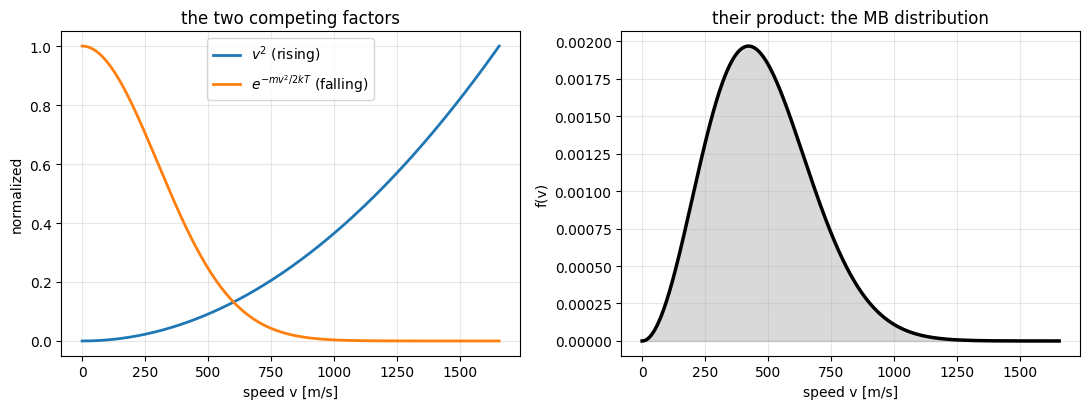

In [2]:
m = 28 * amu; T = 300.0
vrms = mb.rms_speed(m, T)
v = np.linspace(0, 3.2*vrms, 1000)
a = m / (2*k*T)
v2 = v**2
boltz = np.exp(-a * v**2)
f = mb.maxwell_boltzmann_pdf(v, m, T)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(v, v2/v2.max(), lw=2, label="$v^2$ (rising)")
ax[0].plot(v, boltz, lw=2, label="$e^{-mv^2/2kT}$ (falling)")
ax[0].set(xlabel="speed v [m/s]", ylabel="normalized", title="the two competing factors")
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(v, f, lw=2.5, color="k")
ax[1].fill_between(v, f, alpha=0.15, color="k")
ax[1].set(xlabel="speed v [m/s]", ylabel="f(v)", title="their product: the MB distribution")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. The three speeds: most-probable, mean, rms

Three numbers summarize the curve, all $\sim\sqrt{kT/m}$ but with different constants:
$$v_{mp}=\sqrt{\tfrac{2kT}{m}}\ (\text{peak}),\quad
  v_{avg}=\sqrt{\tfrac{8kT}{\pi m}},\quad
  v_{rms}=\sqrt{\tfrac{3kT}{m}}.$$
They always order $v_{mp}<v_{avg}<v_{rms}$ -- the tail drags the mean and (more so) the rms
above the peak. The rms is the one that carries the energy.

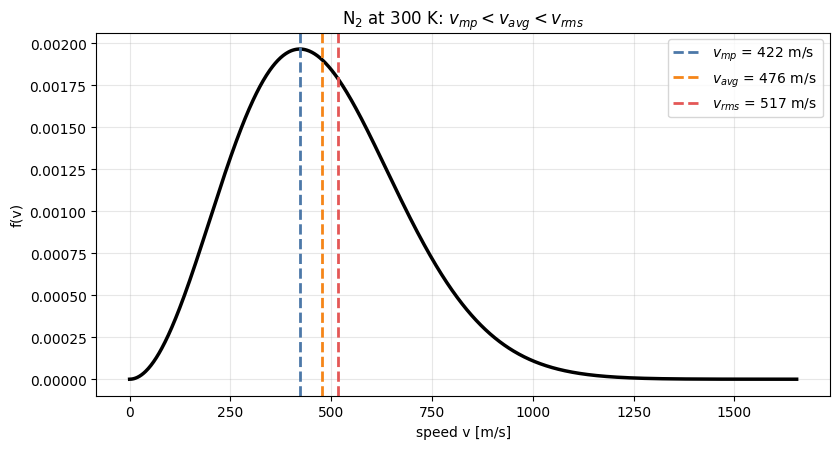

ratios v_mp : v_avg : v_rms = 1 : 1.128 : 1.225  (= 1 : sqrt(4/pi) : sqrt(3/2))


In [3]:
vmp, vavg = mb.most_probable_speed(m, T), mb.mean_speed(m, T)
plt.figure(figsize=(8.5, 4.6))
plt.plot(v, f, lw=2.5, color="k")
for val, name, c in [(vmp, "$v_{mp}$", "#4C78A8"), (vavg, "$v_{avg}$", "#F58518"),
                     (vrms, "$v_{rms}$", "#E45756")]:
    plt.axvline(val, color=c, ls="--", lw=2, label=f"{name} = {val:.0f} m/s")
plt.xlabel("speed v [m/s]"); plt.ylabel("f(v)")
plt.title("N$_2$ at 300 K: $v_{mp} < v_{avg} < v_{rms}$")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("ratios v_mp : v_avg : v_rms = 1 : %.3f : %.3f  (= 1 : sqrt(4/pi) : sqrt(3/2))"
      % (vavg/vmp, vrms/vmp))

## 3. Hotter gas = faster and more spread out

Raise the temperature and the whole distribution shifts right and flattens: the atoms speed
up ($v_{rms}\propto\sqrt T$) and their speeds spread more. The area stays 1 (same number of
atoms), so a taller peak would be narrower -- heat trades height for width.

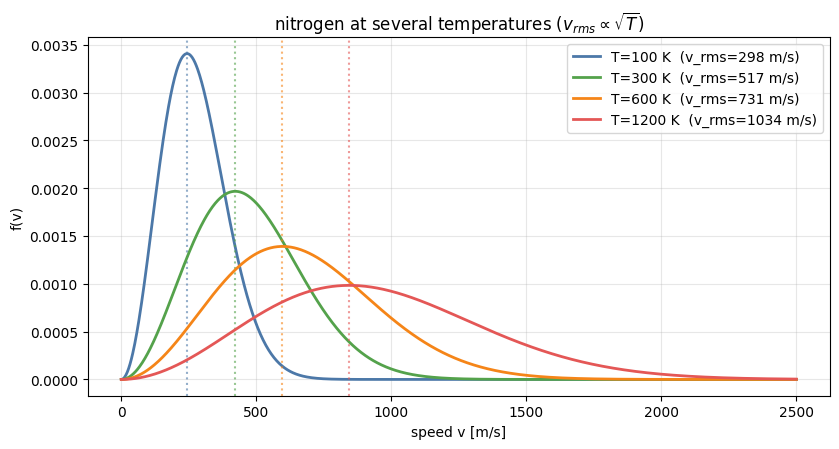

In [4]:
plt.figure(figsize=(8.5, 4.6))
vv = np.linspace(0, 2500, 1000)
for Tk, c in zip((100, 300, 600, 1200), ["#4C78A8", "#54A24B", "#F58518", "#E45756"]):
    plt.plot(vv, mb.maxwell_boltzmann_pdf(vv, m, Tk), lw=2, color=c,
             label=f"T={Tk} K  (v_rms={mb.rms_speed(m,Tk):.0f} m/s)")
    plt.axvline(mb.most_probable_speed(m, Tk), color=c, ls=":", alpha=0.6)
plt.xlabel("speed v [m/s]"); plt.ylabel("f(v)")
plt.title("nitrogen at several temperatures ($v_{rms}\\propto\\sqrt{T}$)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Lighter atoms move faster

At the same temperature every gas has the same average kinetic energy $\tfrac32 kT$, so the
lighter atoms must move faster ($v_{rms}\propto 1/\sqrt m$). Helium out-races xenon by
$\sqrt{131/4}\approx 5.7\times$. This is why hydrogen and helium leak out of the atmosphere
(their fast tails exceed escape velocity) while nitrogen stays.

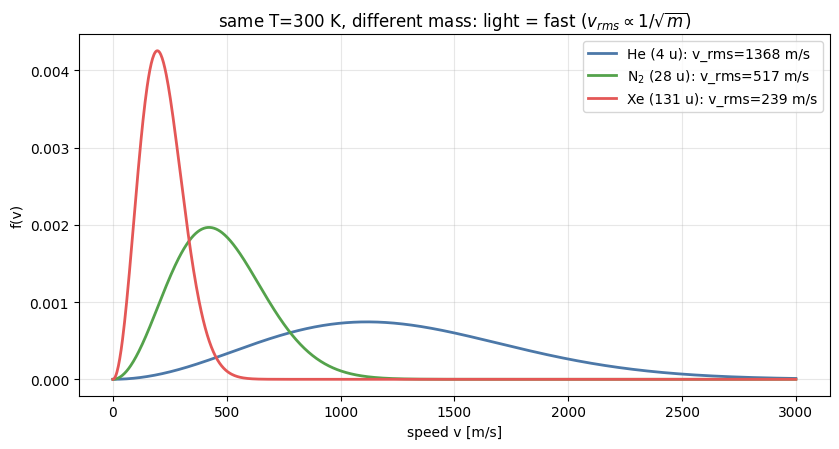

He is 5.7x faster than Xe (= sqrt(131/4) = 5.7)


In [5]:
plt.figure(figsize=(8.5, 4.6))
vv = np.linspace(0, 3000, 1000)
for mass_amu, name, c in [(4, "He", "#4C78A8"), (28, "N$_2$", "#54A24B"), (131, "Xe", "#E45756")]:
    mm = mass_amu * amu
    plt.plot(vv, mb.maxwell_boltzmann_pdf(vv, mm, 300), lw=2, color=c,
             label=f"{name} ({mass_amu} u): v_rms={mb.rms_speed(mm,300):.0f} m/s")
plt.xlabel("speed v [m/s]"); plt.ylabel("f(v)")
plt.title("same T=300 K, different mass: light = fast ($v_{rms}\\propto 1/\\sqrt{m}$)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("He is %.1fx faster than Xe (= sqrt(131/4) = %.1f)"
      % (mb.rms_speed(4*amu,300)/mb.rms_speed(131*amu,300), np.sqrt(131/4)))

## 5. Check: the distribution really gives $\langle KE\rangle=\tfrac32 kT$

Integrate $\tfrac12 m v^2 f(v)$ over all speeds and you must get the equipartition energy
$\tfrac32 kT$ -- the whole point of temperature. Confirmed numerically, along with the
normalization and the mean/rms speeds.

In [6]:
norm, v1, v2 = mb._moments(m, T)
print("integral of f(v) dv        = %.4f   (should be 1)" % norm)
print("<v>       from integral     = %.1f m/s vs v_avg %.1f" % (v1, mb.mean_speed(m,T)))
print("sqrt<v^2> from integral     = %.1f m/s vs v_rms %.1f" % (np.sqrt(v2), mb.rms_speed(m,T)))
print("<KE> = 1/2 m <v^2>          = %.4e J" % (0.5*m*v2))
print("3/2 kT (equipartition)      = %.4e J" % mb.average_kinetic_energy(T))
print("match:", np.isclose(0.5*m*v2, mb.average_kinetic_energy(T), rtol=1e-3))

integral of f(v) dv        = 1.0000   (should be 1)
<v>       from integral     = 476.3 m/s vs v_avg 476.3
sqrt<v^2> from integral     = 517.0 m/s vs v_rms 517.0
<KE> = 1/2 m <v^2>          = 6.2129e-21 J
3/2 kT (equipartition)      = 6.2129e-21 J
match: True


## What the plots say

* $f(v)$ is $v^2$ (rising) times the Boltzmann factor (falling) -- a bell with a long
  high-speed tail.
* Three speeds order $v_{mp}<v_{avg}<v_{rms}$ (1 : $\sqrt{4/\pi}$ : $\sqrt{3/2}$); the tail
  pulls the averages above the peak.
* Hotter $\Rightarrow$ faster and broader ($v_{rms}\propto\sqrt T$); lighter $\Rightarrow$
  faster ($v_{rms}\propto1/\sqrt m$), so He outruns Xe ~5.7x.
* Integrating $\tfrac12 mv^2 f(v)$ returns $\tfrac32 kT$ -- equipartition, the classical limit
  of the same Boltzmann factor in `dgs/quantum_oscillator.py` and `dgs/blackbody.py`.